# Importance Sampling for observable estimation with Foundation NQS
---

In Variational Monte Carlo (VMC) we estimate expectation values with statistical averages

$$
\langle O \rangle_\psi = \frac{\langle \psi | \hat O | \psi\rangle}{\langle \psi | \psi \rangle}
\approx \frac{1}{N_s} \sum_{i=1}^{N_s} O_\text{loc}(\sigma_i),
\qquad
O_\text{loc}(\sigma) = \sum_\eta \langle\sigma|\hat O|\eta\rangle \frac{\psi(\eta)}{\psi(\sigma)},
$$

where $p(\sigma) = |\psi(\sigma)|^2 / \lVert\psi\rVert^2$ is the Born probability from which the samples $\{\sigma_i\}_{i=1}^{N_s}$ are drawn, $\sigma_i \sim p(\sigma)$.

### Sampling is a bottleneck for Foundation NQS
---

After optimizatio on $H(\lambda)$, the Foundation NQS provides parameters for $\psi(\sigma; \lambda)$
across the full parameter range. Computing observables at a given $\lambda_0$ still
requires extracting $\psi(\sigma; \lambda_0)$ and thermalizing its MCMC chains,
a fine sweep would mean a full MCMC at every point, wasteful since nearby $\lambda_0$
give nearly identical $|\psi(\sigma; \lambda_0)|^2$.

A natural fix is **reweighting** via importance sampling, introduced below.

## Reweighting identity and Effective Sample Size (ESS)
---
We want to estimate $\langle O\rangle$ for a **target** state $\psi_\text{tgt}$,
but we only have samples $\{\sigma_i\}$ drawn from a **reference** state $\psi_\text{ref}$.
Defining the weights

$$
w_i = \frac{|\psi_\text{tgt}(\sigma_i)|^2}{|\psi_\text{ref}(\sigma_i)|^2},
$$

a few lines of algebra give the **self-normalized IS** estimator:

$$
\widehat{\langle O\rangle}_\text{tgt}
= \frac{\sum_i w_i\, O_\text{loc}^\text{tgt}(\sigma_i)}{\sum_i w_i}.
$$


The standard diagnostic for IS quality is the **Effective Sample Size**:

$$
\text{ESS} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2},
\qquad 1 \le \text{ESS} \le N,
$$

i.e. the number of *equally-weighted* samples that would give the same
statistical power as the $N$ unevenly-weighted ones.

| ESS / N | Meaning |
|---------|:--------|
| $\approx 1$ | All weights equal ($\psi_\text{tgt} = \psi_\text{ref}$). Perfect reuse. |
| $\gtrsim 0.1$ | Reasonable overlap. IS estimate trustworthy. |
| $\lesssim 0.01$ | A few samples dominate. Estimator degenerate. |

the method `expect_is` reports $\sigma_{\bar O} = \sqrt{\mathrm{Var}_w(O_\text{loc}) / \text{ESS}}$,
so a collapsing ESS inflates the error bar accordingly.

## Example: fine sweep for the transverse-field Ising chain
---

We train a small Foundation NQS for the one-dimensional transverse-field Ising
model across a range of transverse fields $h$, pick a few anchor points, and
produce a fine sweep by reweighting.

In [11]:
import os
os.environ["NETKET_EXPERIMENTAL_SHARDING"] = "1"
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import netket as nk
import netket_foundation as nkf
from netket_foundation._src.model.vit import ViTFNQS
from netket_foundation.expectation_value import expect_is, qfi_is
from netket_foundation._src.vqs.fidelity_susceptibility import susceptibility

The one-dimensional transverse-field Ising model on $L=10$ spins with periodic boundary conditions has the following hamiltonian:

$$
\hat H(h_0) = -\sum_{i=1}^L \sigma^z_i \sigma^z_{i+1}
              - h_0 \sum_{i=1}^L \sigma^x_i.
$$

where $\sigma^\alpha_{L+i} = \sigma_{i}$ for $\alpha \in [x,y,z]$ and $i=1,...,L$

In [12]:
L = 10
hi = nk.hilbert.Spin(0.5, L)
graph = nk.graph.Chain(L, pbc=True)

ps = nkf.ParameterSpace(N=1, min=0.75, max=2.0)

def create_operator(params):
    """Build the Ising Hamiltonian for a given 1D array of parameters."""
    assert params.shape == (1,)
    h = params[0]
    ha_X = sum(nkf.operator.sigmax(hi, i) for i in range(L))
    ha_ZZ = sum(
        nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % L)
        for i in range(L)
    )
    return -h * ha_X - ha_ZZ

# Parametrised operator for the FNQS driver.
ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

# Magnetization operators (parameter-independent).
# PauliStringsJax does not support division, so we multiply by (1/L).
Mz = sum(nkf.operator.sigmaz(hi, i) for i in range(L)) * (1.0 / L)
Mz2 = Mz @ Mz

print(f"System: 1D Ising, L={L}, h0 in [{ps._min}, {ps._max}]")

System: 1D Ising, L=10, h0 in [0.75, 2.0]


### Training of the Foundational NQS
---

We use a small ViTFNQS trained with the
natural-gradient VMC driver across 8 replicas, each at a different
$h_0$ uniformly spaced in $[0.8, 1.2]$.

In [13]:
import optax

# --- model ---
ma = ViTFNQS(
    num_layers=2,
    d_model=12,
    heads=4,
    L_eff=L // 2,        # patch size: 2 spins per patch
    n_coups=ps.size,     # number of Hamiltonian parameters
    b=2,
    complex=False,
    disorder=False,
    transl_invariant=True,
    two_dimensional=False,
)

# --- sampler & foundational state ---
sa = nk.sampler.MetropolisLocal(hi, n_chains=256)
vs = nkf.FoundationalQuantumState(sa, ma, ps, n_samples=1024, n_replicas=8, seed=1)

# Distribute the 8 replicas evenly across the parameter range.
vs.parameter_array = jnp.linspace(0.75, 2.0, vs.n_replicas).reshape(-1, 1)

# --- training ---
N_ITER = 300
learning_rate = 0.01
optimizer = optax.sgd(learning_rate)
diag_shift_schedule = optax.exponential_decay(1e-2, 
                                              transition_steps=32, 
                                              decay_rate=0.5
                                        )
gs = nkf.VMC_NG(ha_p, 
                optimizer, 
                variational_state=vs, 
                diag_shift=diag_shift_schedule,
        )

t0 = time.perf_counter()
gs.run(N_ITER, show_progress=True)
t_train = time.perf_counter() - t0
print(f"Training done in {t_train:.0f} s")

online_statistics: chain_length=4, exponential moving average window: 50, decay=0.920


  0%|          | 0/300 [00:00<?, ?it/s]

Training done in 43 s


###  Anchor points
---

We pick **3 anchor points** ($h_0 = 0.85, 1.0, 1.15$) and run full MCMC at each
one. These will be the *reference states* for IS. All other $h_0$ values in the
fine sweep will borrow samples from their nearest anchor.

For each anchor we call `vs.get_state(h0)` to get the parameters for the state at the transverse field $h_0$, then
we to draw a fresh batch of MCMC samples. 

In [14]:
# Anchor h0 values where we do full MCMC.
h_anchors = np.linspace(0.8, 1.9, 7)

# Fine sweep: 21 points across the full range.
h_sweep = np.linspace(0.75, 2.0, 51)

# Build and sample anchor MCStates.
anchor_states = {}
for h0 in h_anchors:
    pars = jnp.array([h0])
    vs_reference = vs.get_state(pars)
    vs_reference.n_samples = 4096 # more samples for the final evaluation
    for _ in range(8):
        vs_reference.sample()  # full burn-in + MCMC chain
    anchor_states[h0] = vs_reference
    print(f"  anchor h0={h0:.2f}  samples: {vs_reference.samples.shape}")

def nearest_anchor(h, anchors=h_anchors):
    """Return the anchor h0 closest to h."""
    return anchors[np.argmin(np.abs(anchors - h))]

  anchor h0=0.80  samples: (256, 16, 10)
  anchor h0=0.98  samples: (256, 16, 10)
  anchor h0=1.17  samples: (256, 16, 10)
  anchor h0=1.35  samples: (256, 16, 10)
  anchor h0=1.53  samples: (256, 16, 10)
  anchor h0=1.72  samples: (256, 16, 10)
  anchor h0=1.90  samples: (256, 16, 10)


For each $h_0$ in the fine sweep we:

- Find the nearest anchor.
- Build the target `MCState` via `vs.get_state(h0)` to get its `.variables`.
- Call `expect_is(H, mc_anchor, target_vars)` to estimate $\langle H(h_0)\rangle$
   and $\langle M_z^2\rangle$ using the anchor's samples reweighted.




In [15]:
# --- warm-up: compile expect_is with one throwaway call per anchor ---
for h0, mc in anchor_states.items():
    _w = expect_is(create_operator(jnp.array([h0])), mc, mc.variables)
    jax.block_until_ready(_w.stats.mean)

is_E, is_E_err, is_Mz2, is_Mz2_err = [], [], [], []
is_ess_frac, is_anchor_used = [], []

for h0 in h_sweep:
    # 1. Nearest anchor
    h_anc = nearest_anchor(h0)
    mc_ref = anchor_states[h_anc]

    # 2. Target variables (forward pass, no MCMC)
    pars = jnp.array([h0])
    tgt_vars = vs.get_state(pars).variables

    # 3. IS estimates
    H_tgt = create_operator(pars)
    r_E   = expect_is(H_tgt, mc_ref, tgt_vars)
    r_Mz2 = expect_is(Mz2,   mc_ref, tgt_vars)

    is_E.append(float(r_E.stats.mean.real))
    is_E_err.append(float(r_E.stats.error_of_mean))
    is_Mz2.append(float(r_Mz2.stats.mean.real))
    is_Mz2_err.append(float(r_Mz2.stats.error_of_mean))
    is_ess_frac.append(r_E.ess_fraction)
    is_anchor_used.append(h_anc)

print(f"IS sweep done ({len(h_sweep)} points, {len(h_anchors)} anchors).")

IS sweep done (51 points, 7 anchors).


### Baseline: full MCMC at every point
---

For comparison, we now do what one would do without IS: for each $h_0$ in the same
sweep, call `vs.get_state(h0)`, run full MCMC, and compute observables with
`MCState.expect`. 



In [16]:
# --- warm-up ---
_mc_w = vs.get_state(jnp.array([1.0]))
_mc_w.sample()
_ = _mc_w.expect(create_operator(jnp.array([1.0])))
_ = _mc_w.expect(Mz2)

base_E, base_E_err, base_Mz2, base_Mz2_err = [], [], [], []

for h0 in h_sweep:
    pars = jnp.array([h0])
    mc = vs.get_state(pars)
    mc.n_samples = 4096 # more samples for the final evaluation
    for _ in range(8):
        mc.sample()  # full burn-in + MCMC every time

    H_h = create_operator(pars)
    e   = mc.expect(H_h)
    mz2 = mc.expect(Mz2)

    base_E.append(float(e.mean.real))
    base_E_err.append(float(e.error_of_mean))
    base_Mz2.append(float(mz2.mean.real))
    base_Mz2_err.append(float(mz2.error_of_mean))

print(f"Baseline sweep done ({len(h_sweep)} points).")

Baseline sweep done (51 points).


### Exact diagonalisation (ground truth)
---
Since $L=10$ is small enough for exact diagonalisation,
we compute the exact ground-state energy and $\langle M_z^2\rangle$ across the
sweep for comparison.


In [17]:
from scipy.sparse import csr_matrix

Mz2_sparse = Mz2.to_sparse()
exact_E, exact_Mz2 = [], []

for h0 in h_sweep:
    H_h = create_operator(jnp.array([h0]))
    E0, psi0 = nk.exact.lanczos_ed(H_h, k=1, compute_eigenvectors=True)
    psi0 = psi0.reshape(-1)
    exact_E.append(float(E0[0]))
    exact_Mz2.append(float(np.real(psi0.conj() @ (Mz2_sparse @ psi0))))

print("Exact diagonalisation done.")

Exact diagonalisation done.


### Comparison plots

Here we show three panels with the following plots

1. **Energy** $\langle H\rangle$ vs $h_0$: exact (line), baseline (crosses), IS
   (circles with error bars).
2. **Magnetization** $\langle M_z^2\rangle$ vs $h_0$
3. **ESS / N** vs $h_0$: the IS quality diagnostic.


/var/folders/bx/nmyn7rtj3qng43jks7mdjxv80000gp/T/ipykernel_38935/996657660.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_title("Effective Sample Size"); ax.legend(fontsize=8)


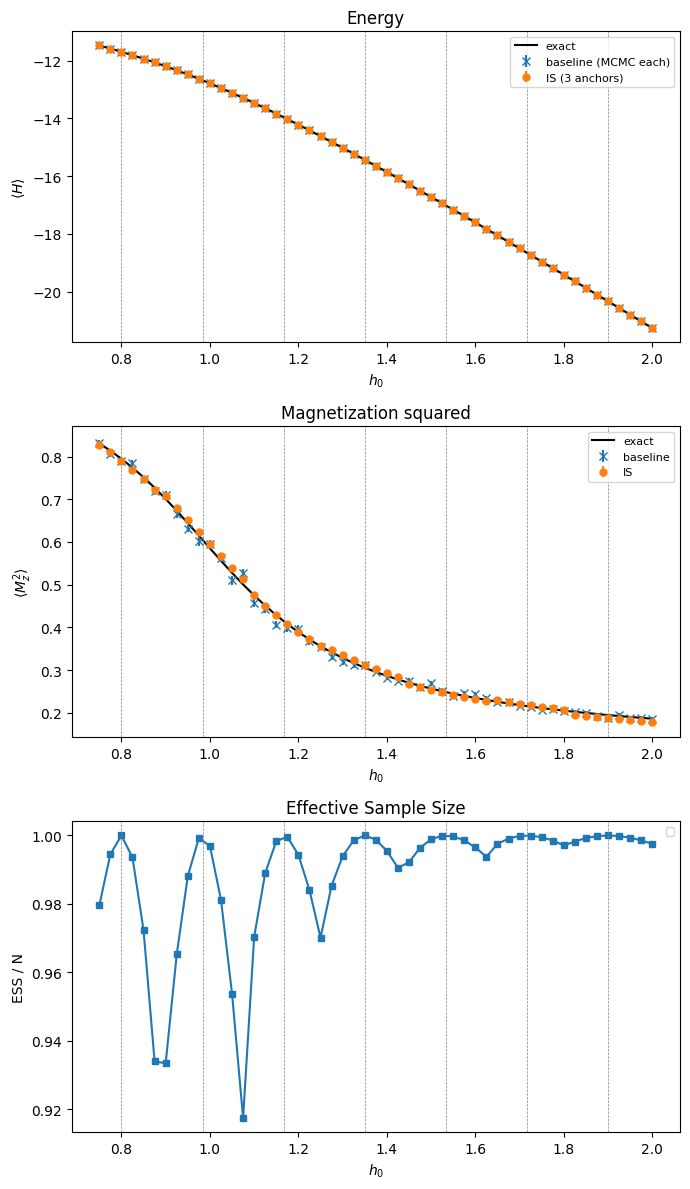

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(7, 12))

# --- Energy ---
ax = axes[0]
ax.plot(h_sweep, exact_E, "k-", lw=1.5, label="exact")
ax.errorbar(h_sweep, base_E, yerr=base_E_err, fmt="x", ms=6, label="baseline (MCMC each)")
ax.errorbar(h_sweep, is_E, yerr=is_E_err, fmt="o", ms=5, label="IS (3 anchors)")
for h_a in h_anchors:
    ax.axvline(h_a, color="gray", ls="--", lw=0.5)
ax.set_xlabel("$h_0$"); ax.set_ylabel("$\\langle H \\rangle$")
ax.set_title("Energy"); ax.legend(fontsize=8)

# --- Mz^2 ---
ax = axes[1]
ax.plot(h_sweep, exact_Mz2, "k-", lw=1.5, label="exact")
ax.errorbar(h_sweep, base_Mz2, yerr=base_Mz2_err, fmt="x", ms=6, label="baseline")
ax.errorbar(h_sweep, is_Mz2, yerr=is_Mz2_err, fmt="o", ms=5, label="IS")
for h_a in h_anchors:
    ax.axvline(h_a, color="gray", ls="--", lw=0.5)
ax.set_xlabel("$h_0$"); ax.set_ylabel("$\\langle M_z^2 \\rangle$")
ax.set_title("Magnetization squared"); ax.legend(fontsize=8)

# --- ESS ---
ax = axes[2]
ax.plot(h_sweep, is_ess_frac, "s-", ms=5)
# ax.axhline(0.1, color="r", ls=":", label="threshold 0.1")
for h_a in h_anchors:
    ax.axvline(h_a, color="gray", ls="--", lw=0.5 )
ax.set_xlabel("$h_0$"); ax.set_ylabel("ESS / N")
# ax.set_ylim(0, 1.05)
ax.set_title("Effective Sample Size"); ax.legend(fontsize=8)


plt.tight_layout(); plt.show()

## Quantum Fisher information: IS vs direct MCMC
---

The fidelity susceptibility with respect to $h$,

$$
\chi(h) = \mathrm{Var}_{|\psi(h)|^2}\!\left[\partial_h \log\psi(\sigma;\,h)\right],
$$

peaks at the quantum phase transition $h_c = 1$. We compare two ways to evaluate it:

- **Direct MCMC** — call `susceptibility(mc)` on the 7 already-sampled anchor states. Each point uses its own freshly-drawn samples.
- **IS sweep** — call `qfi_is(vs, h0, mc_ref)` for all 51 points in `h_sweep`, reweighting from the nearest anchor. No additional MCMC required.

In [19]:
# Direct QFI at anchor points (reuses already-sampled states, no extra MCMC).
qfi_direct_h   = list(anchor_states.keys())
qfi_direct_vals = [float(susceptibility(mc)["Mean"][0, 0]) for mc in anchor_states.values()]

# IS sweep over the fine grid.
qfi_is_vals, qfi_is_ess = [], []
for h0 in h_sweep:
    result = qfi_is(vs, jnp.array([h0]), anchor_states[nearest_anchor(h0)])
    qfi_is_vals.append(float(result.chi[0, 0]))
    qfi_is_ess.append(result.ess_fraction)

qfi_is_vals = np.array(qfi_is_vals)
qfi_is_ess  = np.array(qfi_is_ess)
print(f"QFI IS sweep done. Peak at h = {h_sweep[np.argmax(qfi_is_vals)]:.2f}")

QFI IS sweep done. Peak at h = 0.93


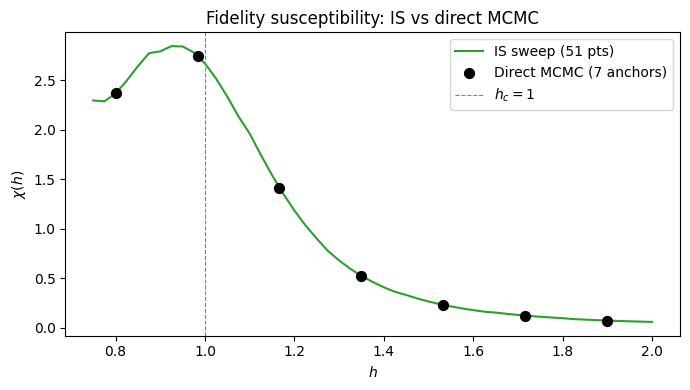

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(h_sweep, qfi_is_vals, "-", color="tab:green", lw=1.5, label="IS sweep (51 pts)")
ax.scatter(qfi_direct_h, qfi_direct_vals, color="k", s=50, zorder=5, label="Direct MCMC (7 anchors)")
ax.axvline(1.0, ls="--", color="gray", lw=0.8, label="$h_c = 1$")
ax.set_xlabel("$h$")
ax.set_ylabel(r"$\chi(h)$")
ax.set_title("Fidelity susceptibility: IS vs direct MCMC")
ax.legend()

plt.tight_layout()
plt.show()